In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
# from pysheds.grid import Grid
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import rasterio
import geopandas as gpd
from rasterio.transform import from_origin
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio.plot
from rasterio.plot import plotting_extent
import whitebox
%matplotlib inline
wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(".")

In [2]:
wbt = whitebox.WhiteboxTools()
wbt.set_whitebox_dir("/srv/conda/envs/notebook/lib/python3.10/site-packages/whitebox/whitebox_tools")
print(wbt.exe_path)
import os
print("Exists:", os.path.isfile(wbt.exe_path))
print("Executable:", os.access(wbt.exe_path, os.X_OK))

wbt = whitebox.WhiteboxTools()
# print("WhiteboxTools exe path:", wbt.exe_path)  # Should print the path to whitebox_tools.exe

/srv/conda/envs/notebook/lib/python3.10/site-packages/whitebox/whitebox_tools
Exists: True
Executable: True


In [3]:
# with rasterio.open('0-dem.tif') as src:
#     data = src.read(1)
# print(src.crs)
# plt.imshow(data, cmap='cubehelix', vmin=0)
# plt.title('DEM-masked')
# plt.show()

In [4]:
# Preprocess crs of pourpoints:
pourpoints = gpd.read_file("pourpoints/pourpoint_utm.shp")
pourpoints = pourpoints.to_crs("EPSG:32760")
pourpoints.to_file("pourpoints/pourpoint_utm.shp")
print(pourpoints.crs)

wbt.snap_pour_points("pourpoints/pourpoint_utm.shp", "5-d8-flow-accumulation.tif", "pourpoints/snapped-pourpoints.shp", 60)
# print(wbt.tool_help("snap_pour_points"))

# wbt.snap_pour_points(pourpoints, "pourpoints/snapped-pourpoints.shp", 60)

EPSG:32760
./whitebox_tools --run="SnapPourPoints" --pour_pts='pourpoints/pourpoint_utm.shp' --flow_accum='5-d8-flow-accumulation.tif' --output='pourpoints/snapped-pourpoints.shp' --snap_dist='60' -v --compress_rasters=False

*****************************
* Welcome to SnapPourPoints *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
thread 'main' panicked at whitebox-vector/src/shapefile/mod.rs:238:56:
called `Result::unwrap()` on an `Err` value: Os { code: 2, kind: NotFound, message: "No such file or directory" }
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


0

In [5]:
# with rasterio.open(
#     '4-d8-flowdir2.tif', 'w',
#     driver='GTiff',
#     height=array.shape[0],
#     width=array.shape[1],
#     count=1,
#     meta = src.meta.copy()
#     meta.update({'nodata': -9999})  # or whatever value is appropriate
#     with rasterio.open('output.tif', 'w', **meta) as dst:
#     dst.write(array, 1)
#     dtype=array.dtype,
#     crs='EPSG:32760',  # or your CRS
#     transform=transform  # must be set correctly
# ) as dst:
#     dst.write(array, 1)

In [6]:
import whiteboxgui
whiteboxgui.show()

In [7]:
raster_path = "/home/jovyan/hydrology-modelling/wbt/dawasamu/4-d8-flow-direction.tif"
points_path = "/home/jovyan/hydrology-modelling/wbt/dawasamu/pourpoints/snapped-pourpoints.shp"

with rasterio.open(raster_path) as src:
    raster = src.read(1)
    nodata = src.nodata
    points = gpd.read_file(points_path)
    if points.crs != src.crs:
        points = points.to_crs(src.crs)
    for idx, row in points.iterrows():
        x, y = row.geometry.x, row.geometry.y
        rowcol = src.index(x, y)
        try:
            val = raster[rowcol[0], rowcol[1]]
            print(f"Point {idx} at ({x}, {y}): Value = {val}")
        except IndexError:
            print(f"Point {idx} at ({x}, {y}): OUTSIDE raster")

Point 0 at (659985.7631366989, 8052240.43432286): OUTSIDE raster


### 2. Fill nodata

2.1. Filter Dimension : 11

2.2. IDW Weight (exponent) value : 2.0

##### Input: `1-dem-masked`
##### Output: `2-cleared-nodata-dem`

### 3. FillDepressions

2.1. Flat increment 
Use a value just above the DEM’s vertical precision (i.e. 0.01 for cm, 1.00 for m

2.2. Max depth
Leave blank or set very high if you want to fill all depressions (the most common case).
##### Input: `2-cleared-nodata-dem`
##### Output: `3-filled-dem`

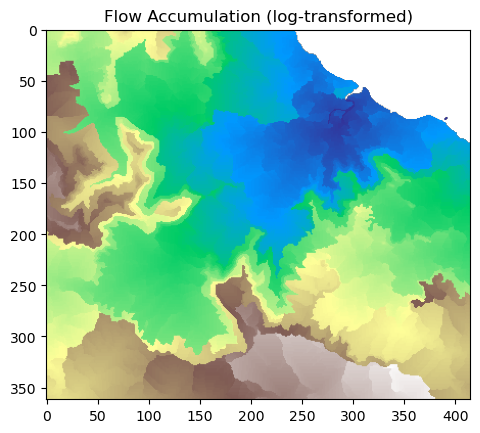

In [8]:
with rasterio.open('3-filled-dem.tif') as src:
    data = src.read(1)
    # Optional: log transform for better visualization
    # data = np.log1p(data)
    plt.imshow(data, cmap='terrain', vmin=0)
    plt.title('Flow Accumulation (log-transformed)')
    plt.show()

#### 4. D8Pointer
Generate Flow direction d8 pointer. Input DEM File, select ouptut file path.
##### Input: `3-filled-dem`
##### Output: `4-d8-flow-direction`

EPSG:32760


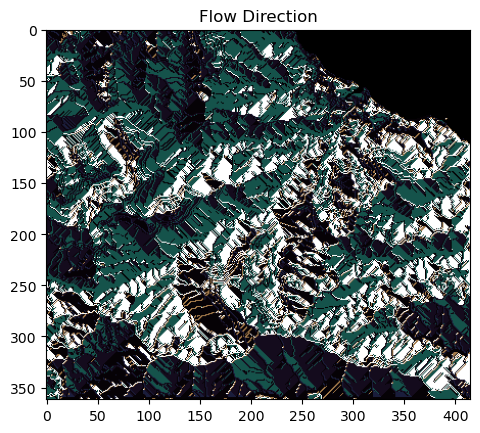

In [9]:
with rasterio.open('4-d8-flow-direction.tif') as src:
    data = src.read(1)
    print(src.crs)
    # Optional: log transform for better visualization
    plt.imshow(data, cmap='cubehelix', vmin=0)
    plt.title('Flow Direction')
    plt.show()

#### 5. D8FlowAccumulation 
Generate Flow accumulation. Input DEM File, select ouptut file path. 
##### Input: `4-d8-flow-direction`
##### Output: `5-d8-flow-accumulation`
a) output type: catchment area  
b) exponent parameter: leave at default 1.1.  
c) is the input raster the d8: tick if yes   
d) convergence threshold: for d8 leave this blank  
e) log transform output: tick if there are several orders of magnitude you want to visualise  
f) clip the upper tail by 1%?: Tick for visualisation

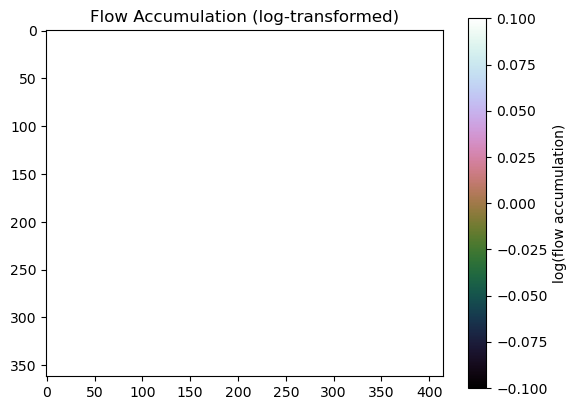

In [10]:
with rasterio.open('5-d8-flow-accumulation.tif') as src:
    data = src.read(1)
    # Optional: log transform for better visualization
    data_log = np.log1p(data)
    plt.imshow(data_log, cmap='cubehelix', vmin=0)
    plt.colorbar(label='log(flow accumulation)')
    plt.title('Flow Accumulation (log-transformed)')
    plt.show()

In [11]:
# # Call a tool, e.g. D8 flow pointer
# wbt.d8_pointer(
#     dem="dem.tif",
#     output="d8_pointer.tif"
# )

# Call watershed tool
wbt.watershed(
    d8_pntr="4-d8-flow-direction.tif",
    pour_pts="pourpoints/snapped-pourpoints.shp",
    output="watersheds.tif"
)

./whitebox_tools --run="Watershed" --d8_pntr='4-d8-flow-direction.tif' --pour_pts='pourpoints/snapped-pourpoints.shp' --output='watersheds.tif' -v --compress_rasters=False

****************************
* Welcome to Watershed     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
thread 'main' panicked at whitebox-tools-app/src/main.rs:72:21:
No such file or directory (os error 2)
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


0

In [12]:


# The most convenient way to run a tool is to use its associated method, e.g.:
# wbt.elev_percentile("DEM.tif", "output.tif", 15, 15)
# You may also provide an optional custom callback for processing output from the
# tool. If you don't provide a callback, and verbose is set to True, tool output
# will simply be printed to the standard output.

# Prints the whitebox-tools help...a listing of available commands
print(wbt.help())

WhiteboxTools Help

The following commands are recognized:
--cd, --wd          Changes the working directory; used in conjunction with --run flag.
--compress_rasters  Sets the compress_raster option in the settings.json file; determines if newly created rasters are compressed. e.g. --compress_rasters=true
-h, --help          Prints help information.
-l, --license       Prints the whitebox-tools license. Tool names may also be used, --license="Slope"
--listtools         Lists all available tools. Keywords may also be used, --listtools slope.
--max_procs         Sets the maximum number of processors used. -1 = all available processors. e.g. --max_procs=2
-r, --run           Runs a tool; used in conjunction with --wd flag; -r="LidarInfo".
--toolbox           Prints the toolbox associated with a tool; --toolbox=Slope.
--toolhelp          Prints the help associated with a tool; --toolhelp="LidarInfo".
--toolparameters    Prints the parameters (in json form) for a specific tool; --toolparame

#### 5. Extract streams tool  
In order to generate pourpoints given that we are not sure where exactly these should be. 
##### Input: `5-d8p-flowaccumulation`
##### Output: `6-extract-streams`
Channelization thresholds: Small watersheds: 50–500, Large areas: 1000–10000
Background value of zero: a) Use zero if you want to perform further raster math or masking. b) Use NoData if you want a clear delineation of "stream vs. not stream" in visualization.


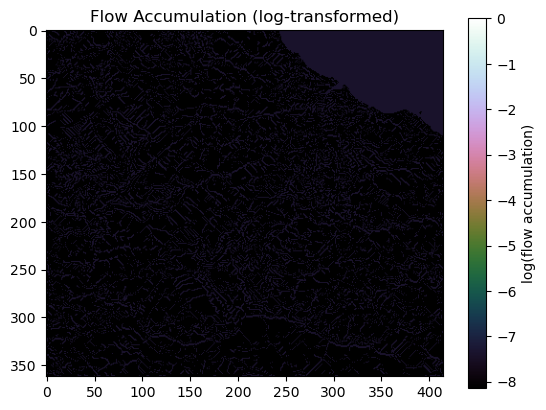

In [18]:
with rasterio.open('5-d8-flow-accumulation.tif') as src:
    data = src.read(1)
    # Optional: log transform for better visualization
    # data_log = np.log1p(data)
    plt.imshow(data, cmap='cubehelix', vmin=0)
    plt.colorbar(label='log(flow accumulation)')
    plt.title('Flow Accumulation (log-transformed)')
    plt.show()

6. Snap pourpoints
Firstly export flow accumulation and extract streams to QGIS. Then digitise pourpoints. Then rasterise. Burn a unique value for each point depending on the id: corresponding to each distinct catchment. Then upload and re-input.    

In order to generate pourpoints given that we are not sure where exactly these should be.

Input: 5-d8p-flowaccumulation
Output: 6-extract-streams